# Desktop parameter search — round 1 (one-at-a-time gradient)

Local sensitivity of the July-2026 desktop KPI (Dec-15 2026, 28-day trailing MA, all head/tailwinds
applied) to each mozaic Prophet/holiday knob. For every knob we run one probe at `center − δ` and one
at `center + δ` around the canonical desktop config (moderate δ), plus a `center` re-run.

- **Runner:** `scripts/run_param_scan.py` (applies the `l` + `o` desktop overlays; stamps `.adj-lo.`).
- **Driver:** `scripts/run_desktop_gradient.py` (this round's 16 probes + center → `results/desktop_gradient_round1/`).
- **KPI filter:** `legacy_desktop / country=ALL / app_name=desktop / segment='{"os": "ALL"}'`, trailing
  `rolling(28)` at 2026-12-15. Pre-headwind; the Win10 headwind (−1,370,000 at Dec-15) is a
  display-layer offset added here, **not** in the scan.
- **Center:** 49,851,092 pre-headwind → 48,481,092 final. **Target:** 48,584,362 final (gap +103,270;
  up to +10k available from softening the headwind).

Outputs: `gradient.csv` + `plots/desktop_gradient_round1/{tornado,<param>}.png`.


In [1]:
# [gr-setup]
import os
import glob
import json
import sys
import time
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from google.cloud import bigquery

# Anchor at git root so relative paths resolve regardless of notebook location.
os.chdir(subprocess.run(["git", "rev-parse", "--show-toplevel"],
                        capture_output=True, text=True).stdout.strip())

# --- Paths ---
ROUND_DIR = "research/param-scans/results/desktop_gradient_round1"
PLOTS_DIR = "research/param-scans/plots/desktop_gradient_round1"
ADJUSTMENTS_DIR = "data-official/2026-07/adjustments"  # July headwind spec (linear ramp)
os.makedirs(PLOTS_DIR, exist_ok=True)

# --- Date constants (match the canonical July notebook) ---
DISPLAY_START = pd.Timestamp("2026-01-01")
DISPLAY_END = pd.Timestamp("2026-12-31")
FORECAST_START = pd.Timestamp("2026-06-29")
MEASUREMENT_DATE = pd.Timestamp("2026-12-15")
BQ_START = "2025-12-04"  # 28d lookback before DISPLAY_START for the MA warmup

# --- Reference numbers (verified this cycle) ---
CENTER_KPI_PRE = 49_851_092      # center config, pre-headwind Dec-15 28d-MA
HEADWIND_DEC15 = -1_370_000      # display-layer Win10 headwind at the anchor
CURRENT_FINAL = 48_481_092       # = CENTER_KPI_PRE + HEADWIND_DEC15
TARGET_FINAL = 48_584_362        # stakeholder param-search target (final KPI)

# --- Probe grid (mirror scripts/run_desktop_gradient.py) ---
# (config_field, short_label, center, minus_delta, plus_delta)
PARAMS = [
    ("prophet_changepoint_prior_scale", "cps",    0.15983, 0.12983, 0.18983),
    ("prophet_recent_weeks",            "recent", 13,      11,      15),
    ("prophet_changepoint_range",       "cpr",    0.7,     0.65,    0.75),
    ("prophet_n_changepoints",          "ncp",    25,      20,      30),
    ("holiday_threshold",               "thresh", -0.032,  -0.037,  -0.027),
    ("holiday_max_radius",              "hmaxr",  5,       4,       6),
    ("holiday_min_radius",              "hminr",  3,       2,       4),
    ("holiday_effect_floor",            "clip",   -0.6,    -0.7,    -0.5),
]
LABELS = {short: field for field, short, *_ in PARAMS}

print(f"Target final KPI : {TARGET_FINAL:,}")
print(f"Current final KPI: {CURRENT_FINAL:,}  (gap {TARGET_FINAL - CURRENT_FINAL:+,})")
print(f"Round dir        : {ROUND_DIR}")


Target final KPI : 48,584,362
Current final KPI: 48,481,092  (gap +103,270)
Round dir        : research/param-scans/results/desktop_gradient_round1


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


In [2]:
# [gr-helpers]
# Reuse the canonical seam-matched display MA so the forecast curves match the exported
# canonical PNGs/CSVs. Actuals use the plain trailing daily_to_28ma. IMPORTANT: this uses the
# TRAILING 28d-MA convention (display_ma / rolling(28)) — NOT the centered rolling used in the
# older param_scan_exploration.ipynb, which does not match the canonical Dec-15 number.
sys.path.insert(0, "data-official/2026-06")
from export_canonical_curves import display_ma  # noqa: E402

SEG_ALL = '{"os": "ALL"}'


def daily_to_28ma(dates, values):
    """Plain trailing 28-day MA, date-indexed."""
    s = pd.Series(np.asarray(values, dtype=float), index=pd.to_datetime(np.asarray(dates)))
    return s.sort_index().rolling(28).mean()


# --- Display headwind (copied from the canonical notebook helpers so it matches exactly) ---
def render_adjustment(spec, date_index):
    idx = pd.DatetimeIndex(date_index)
    desktop = pd.Series(0.0, index=idx)
    if spec["type"] == "linear_ramp":
        start = pd.Timestamp(spec["start_date"])
        anchor = pd.Timestamp(spec["anchor_date"])
        total_days = (anchor - start).days
        elapsed = np.maximum(0, (idx - start).days)
        desktop[:] = spec.get("desktop_dau", 0) * elapsed / total_days
    elif spec["type"] == "step":
        start = pd.Timestamp(spec["start_date"])
        end = pd.Timestamp(spec["end_date"]) if "end_date" in spec else idx[-1]
        desktop[(idx >= start) & (idx <= end)] = spec.get("desktop_dau", 0)
    return desktop


def load_desktop_adjustment(date_index):
    """Sum all desktop adjustment specs in ADJUSTMENTS_DIR (July = the Win10 headwind ramp)."""
    idx = pd.DatetimeIndex(date_index)
    total = pd.Series(0.0, index=idx)
    for path in sorted(glob.glob(f"{ADJUSTMENTS_DIR}/*.json")):
        with open(path) as f:
            total += render_adjustment(json.load(f), idx)
    return total


def find_probe_parquet(label):
    """Locate a probe's adj-lo forecast parquet under ROUND_DIR/<label>/<slug>/."""
    hits = glob.glob(f"{ROUND_DIR}/{label}/*/mozaic_daily_forecast.2026-06-29.ld-D.adj-lo.parquet")
    return hits[0] if hits else None


def all_desktop_daily(parquet_path):
    """ALL-desktop daily DAU (training + forecast) from a probe parquet."""
    df = pd.read_parquet(parquet_path)
    df["target_date"] = pd.to_datetime(df["target_date"])
    m = df[(df.data_source == "legacy_desktop") & (df.country == "ALL")
           & (df.app_name == "desktop") & (df.segment == SEG_ALL)]
    return m.sort_values("target_date")[["target_date", "dau"]].reset_index(drop=True)


def dec15_pre_headwind(parquet_path):
    """Dec-15 trailing 28d-MA KPI, pre-headwind (matches regenerate_canonical_forecast.all_level)."""
    d = all_desktop_daily(parquet_path)
    s = d.set_index("target_date")["dau"].astype(float)
    return float(s.rolling(28, min_periods=28).mean().loc[MEASUREMENT_DATE])


def forecast_ma_final(parquet_path):
    """Seam-matched 28d-MA forecast curve with the display headwind applied on forecast dates."""
    d = all_desktop_daily(parquet_path)
    ma = display_ma(d["target_date"], d["dau"], FORECAST_START)
    adj = load_desktop_adjustment(ma.index)
    out = ma.copy()
    fmask = out.index >= FORECAST_START
    out[fmask] = out[fmask] + adj[fmask]
    return out


In [3]:
# [gr-actuals]
# Desktop actuals from LEGACY telemetry (Firefox Desktop), same query/clamp as the canonical
# notebook. Cutoff = CURRENT_DATE("America/Los_Angeles") - 2 to avoid a partial most-recent day
# poisoning the trailing MA28 endpoint.
client = bigquery.Client(project="moz-fx-data-bq-data-science")
sql = f"""
    SELECT submission_date AS date, SUM(dau) AS dau
    FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
    WHERE app_name = "Firefox Desktop"
      AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE("America/Los_Angeles") - 2
    GROUP BY submission_date ORDER BY 1
"""
t0 = time.time()
sys.stdout.write("querying desktop actuals...")
sys.stdout.flush()
desktop_actuals = client.query(sql).to_dataframe()
desktop_actuals["date"] = pd.to_datetime(desktop_actuals["date"])
desktop_actual_ma = daily_to_28ma(desktop_actuals["date"], desktop_actuals["dau"])
sys.stdout.write(
    f" {len(desktop_actuals)} rows ({time.time() - t0:.1f}s); "
    f"latest {desktop_actuals['date'].max().date()}\n"
)


querying desktop actuals...

 214 rows (5.6s); latest 2026-07-05


36

In [4]:
# [gradient-table]
# Assemble the one-at-a-time gradient: for each knob, Dec-15 KPI at center-δ, center, center+δ.
center_pre = dec15_pre_headwind(find_probe_parquet("center"))
assert abs(center_pre - CENTER_KPI_PRE) < 1, f"center drift: {center_pre:,.0f} vs {CENTER_KPI_PRE:,}"

rows = []
for field, short, ctr, minus, plus in PARAMS:
    pm, pp = find_probe_parquet(f"{short}__minus"), find_probe_parquet(f"{short}__plus")
    if pm is None or pp is None:
        print(f"WARNING: missing probe(s) for {short}: minus={pm} plus={pp}")
        continue
    kpi_m, kpi_p = dec15_pre_headwind(pm), dec15_pre_headwind(pp)
    rows.append({
        "parameter": LABELS[short],
        "minus_val": minus, "center_val": ctr, "plus_val": plus,
        "kpi_minus_final": kpi_m + HEADWIND_DEC15,
        "kpi_center_final": center_pre + HEADWIND_DEC15,
        "kpi_plus_final": kpi_p + HEADWIND_DEC15,
        "d_minus": kpi_m - center_pre,          # effect of −δ vs center
        "d_plus": kpi_p - center_pre,           # effect of +δ vs center
        "delta_pm": kpi_p - kpi_m,              # gradient signal (+δ minus −δ)
        "raises_kpi": ("+δ" if kpi_p > kpi_m else "−δ"),
    })
grad = pd.DataFrame(rows)
grad["abs_delta"] = grad["delta_pm"].abs()
grad = grad.sort_values("abs_delta", ascending=False).reset_index(drop=True)
grad.to_csv(f"{ROUND_DIR}/gradient.csv", index=False)

print(f"center pre-headwind = {center_pre:,.0f}   final = {center_pre + HEADWIND_DEC15:,.0f}")
print(f"target final        = {TARGET_FINAL:,}   (need {TARGET_FINAL - (center_pre + HEADWIND_DEC15):+,} final)\n")
show = grad[["parameter", "minus_val", "center_val", "plus_val",
             "d_minus", "d_plus", "delta_pm", "raises_kpi"]].copy()
for c in ["d_minus", "d_plus", "delta_pm"]:
    show[c] = show[c].map(lambda v: f"{v:+,.0f}")
print(show.to_string(index=False))
grad


center pre-headwind = 49,851,092   final = 48,481,092
target final        = 48,584,362   (need +103,270.31950865686 final)

                      parameter  minus_val  center_val  plus_val d_minus  d_plus delta_pm raises_kpi
              holiday_threshold   -0.03700    -0.03200  -0.02700 -39,898 +32,072  +71,970         +δ
prophet_changepoint_prior_scale    0.12983     0.15983   0.18983 +20,617 -40,222  -60,839         −δ
      prophet_changepoint_range    0.65000     0.70000   0.75000  +5,354 -46,775  -52,129         −δ
             holiday_min_radius    2.00000     3.00000   4.00000 +21,469  -8,783  -30,252         −δ
             holiday_max_radius    4.00000     5.00000   6.00000 -20,352 -10,057  +10,295         +δ
           holiday_effect_floor   -0.70000    -0.60000  -0.50000      +0  +5,185   +5,185         +δ
           prophet_recent_weeks   11.00000    13.00000  15.00000  +2,648  -1,133   -3,781         −δ
         prophet_n_changepoints   20.00000    25.00000  30.00000  -5

,parameter,minus_val,center_val,plus_val,kpi_minus_final,kpi_center_final,kpi_plus_final,d_minus,d_plus,delta_pm,raises_kpi,abs_delta
0,holiday_threshold,-0.03700,-0.03200,-0.02700,4.844119e+07,4.848109e+07,4.851316e+07,-39897.674526,32071.880753,71969.555279,+δ,71969.555279
1,prophet_changepoint_prior_scale,0.12983,0.15983,0.18983,4.850171e+07,4.848109e+07,4.844087e+07,20616.606067,-40222.178734,-60838.784801,−δ,60838.784801
2,prophet_changepoint_range,0.65000,0.70000,0.75000,4.848645e+07,4.848109e+07,4.843432e+07,5353.917108,-46775.337798,-52129.254906,−δ,52129.254906
3,holiday_min_radius,2.00000,3.00000,4.00000,4.850256e+07,4.848109e+07,4.847231e+07,21468.780625,-8783.023054,-30251.803679,−δ,30251.803679
4,holiday_max_radius,4.00000,5.00000,6.00000,4.846074e+07,4.848109e+07,4.847103e+07,-20351.691701,-10056.807891,10294.883810,+δ,10294.883810
5,holiday_effect_floor,-0.70000,-0.60000,-0.50000,4.848109e+07,4.848109e+07,4.848628e+07,0.000000,5185.405326,5185.405326,+δ,5185.405326
6,prophet_recent_weeks,11.00000,13.00000,15.00000,4.848374e+07,4.848109e+07,4.847996e+07,2647.728697,-1132.837465,-3780.566162,−δ,3780.566162
7,prophet_n_changepoints,20.00000,25.00000,30.00000,4.847517e+07,4.848109e+07,4.847485e+07,-5925.060765,-6237.340388,-312.279624,−δ,312.279624


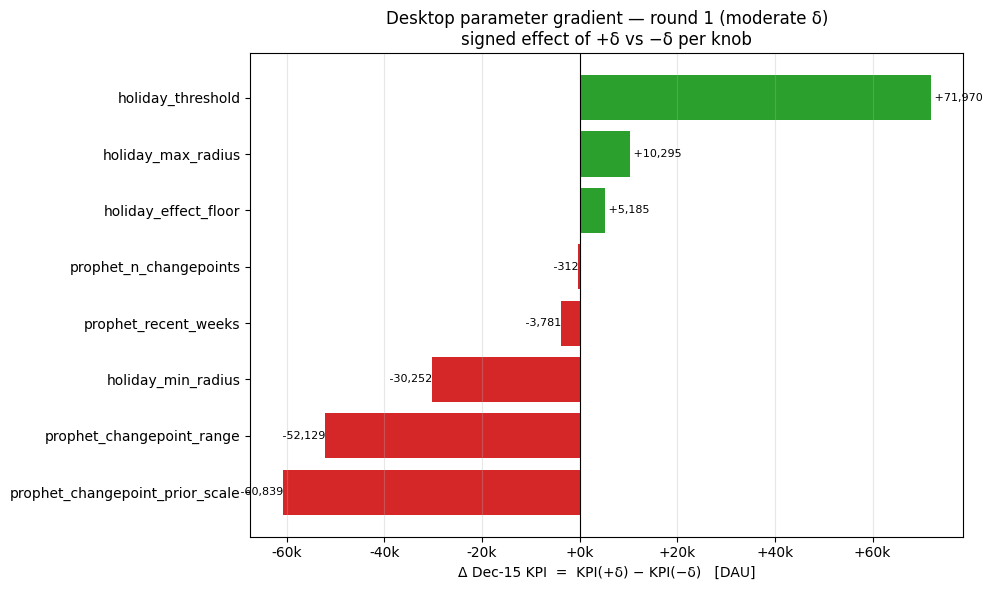

saved research/param-scans/plots/desktop_gradient_round1/tornado.png


In [5]:
# [tornado]
# Signed effect of each knob (KPI(+δ) − KPI(−δ)), largest magnitude at top.
g = grad.sort_values("delta_pm")
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#2ca02c" if v > 0 else "#d62728" for v in g["delta_pm"]]
ax.barh(g["parameter"], g["delta_pm"], color=colors)
ax.axvline(0, color="black", lw=0.8)
for i, v in enumerate(g["delta_pm"]):
    ax.text(v, i, f" {v:+,.0f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=8)
ax.set_xlabel("Δ Dec-15 KPI  =  KPI(+δ) − KPI(−δ)   [DAU]")
ax.set_title("Desktop parameter gradient — round 1 (moderate δ)\n"
             "signed effect of +δ vs −δ per knob", fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:+.0f}k"))
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/tornado.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"saved {PLOTS_DIR}/tornado.png")


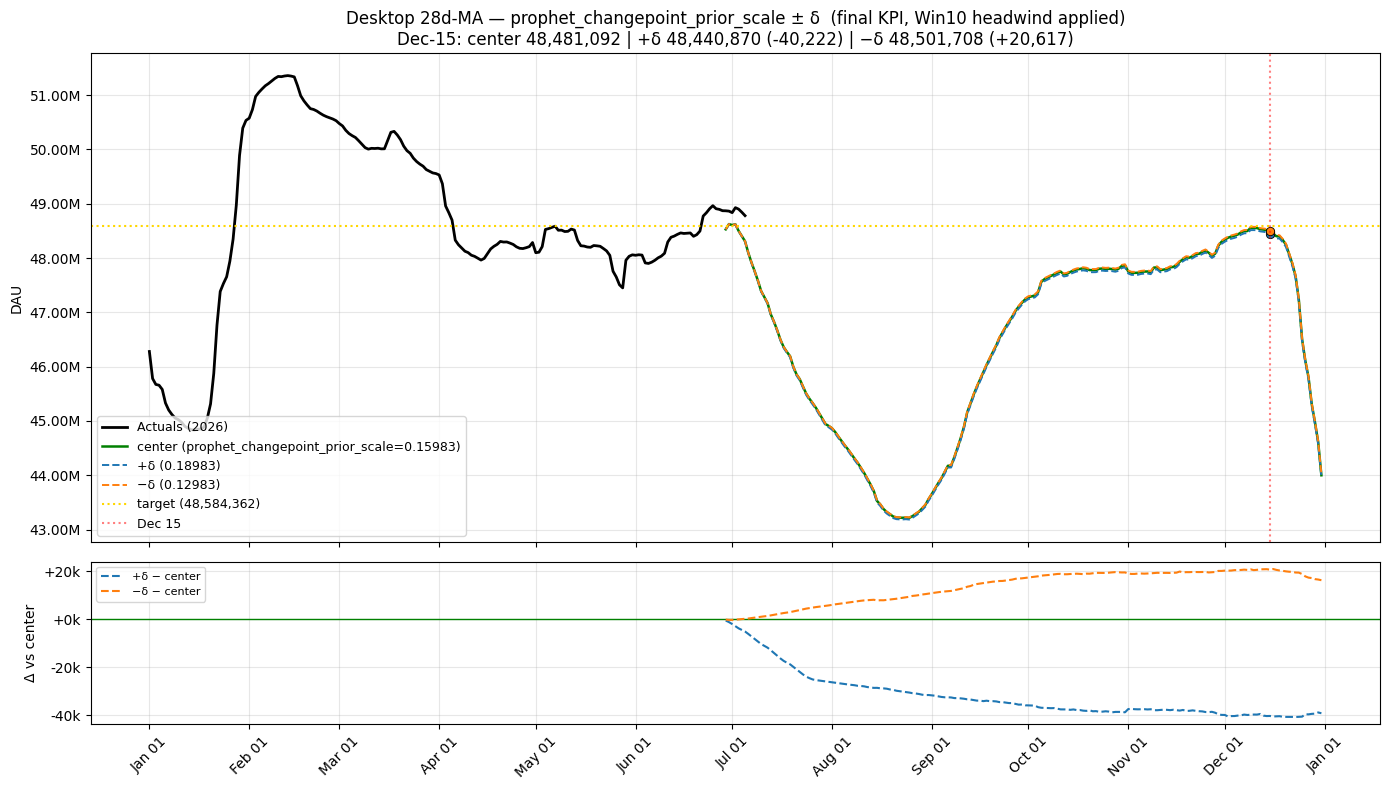

saved research/param-scans/plots/desktop_gradient_round1/cps.png


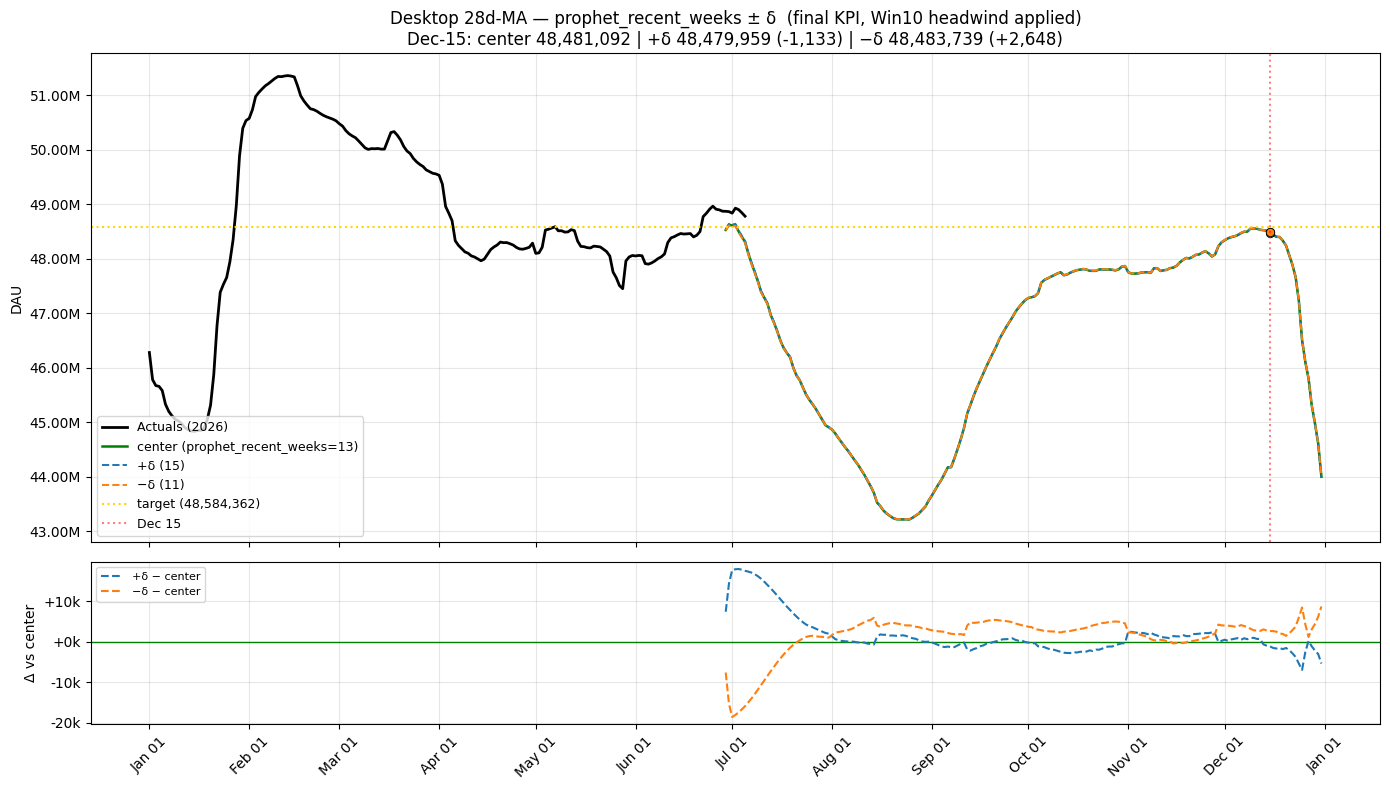

saved research/param-scans/plots/desktop_gradient_round1/recent.png


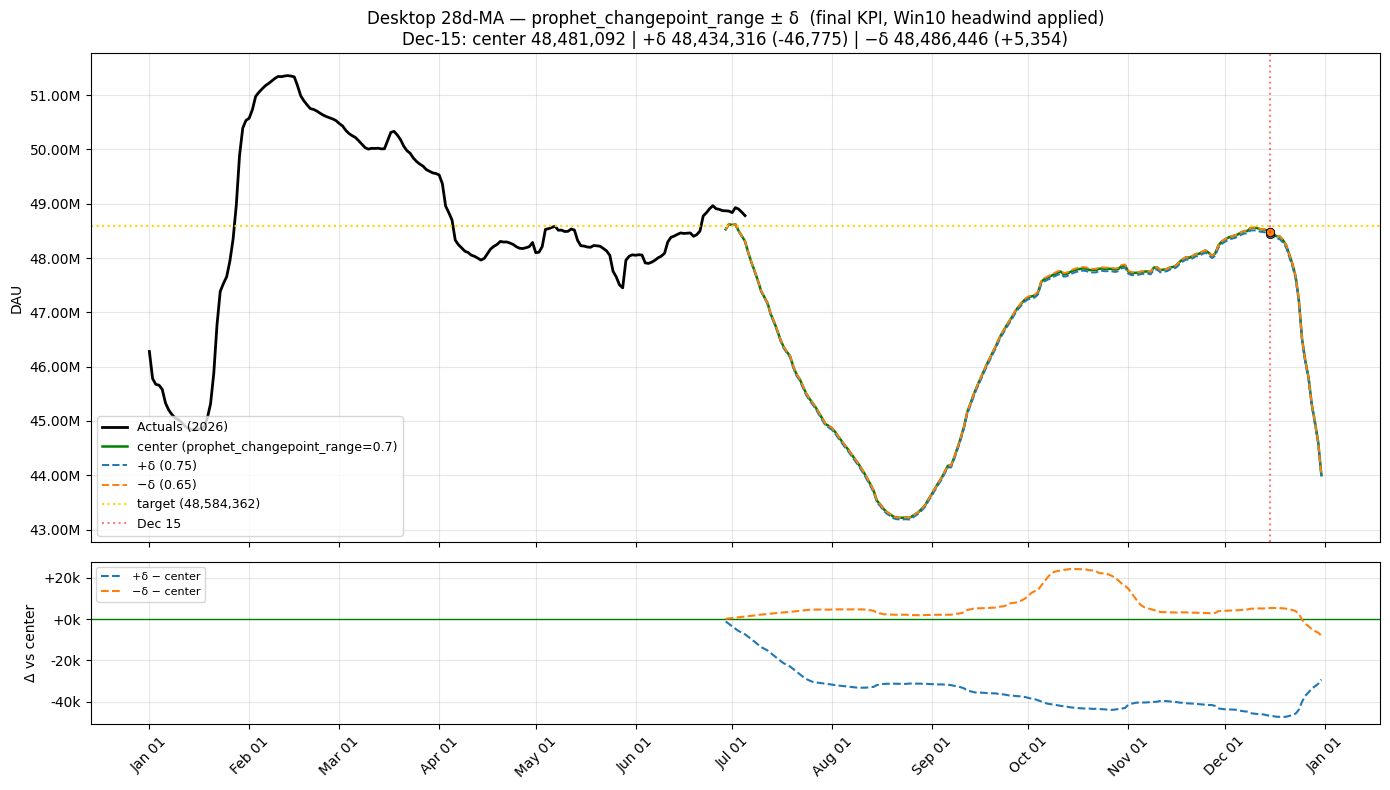

saved research/param-scans/plots/desktop_gradient_round1/cpr.png


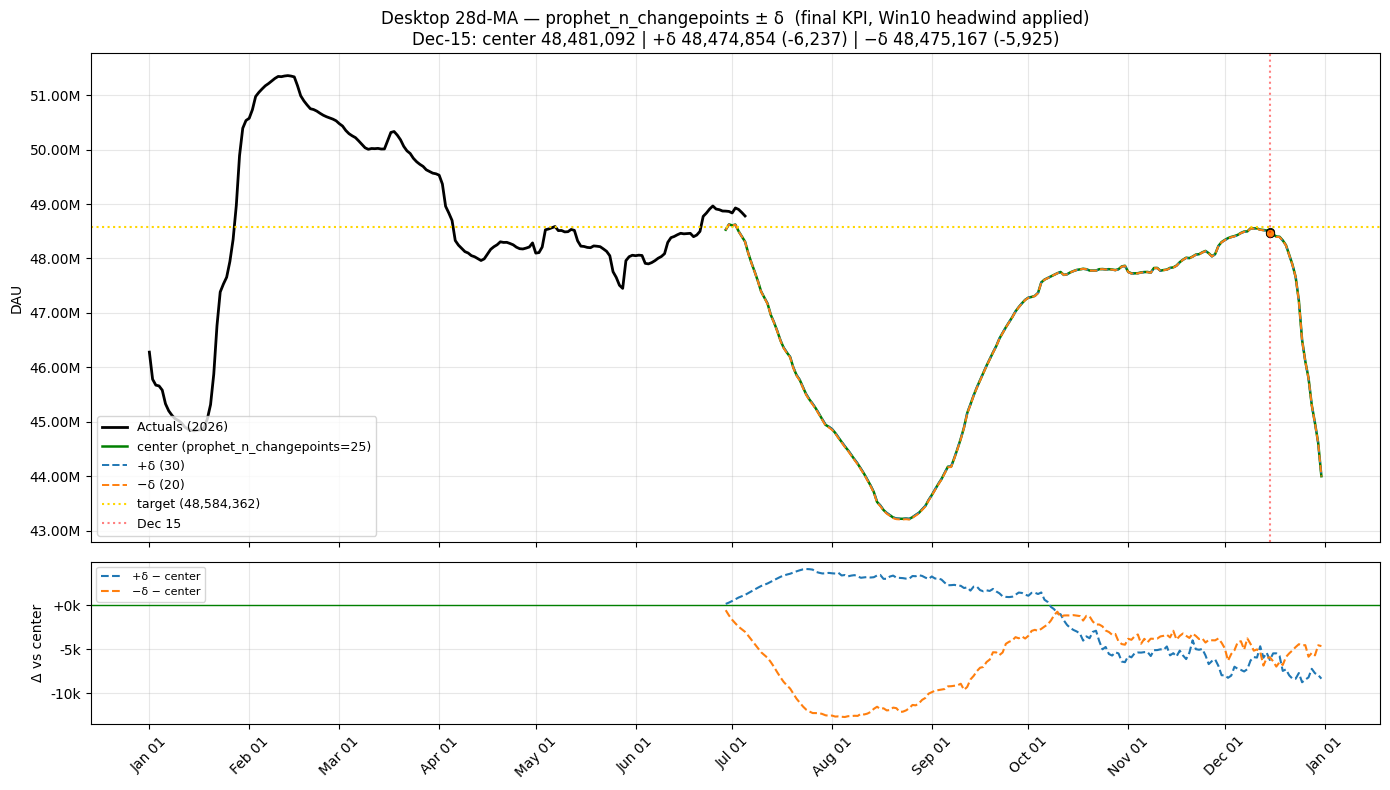

saved research/param-scans/plots/desktop_gradient_round1/ncp.png


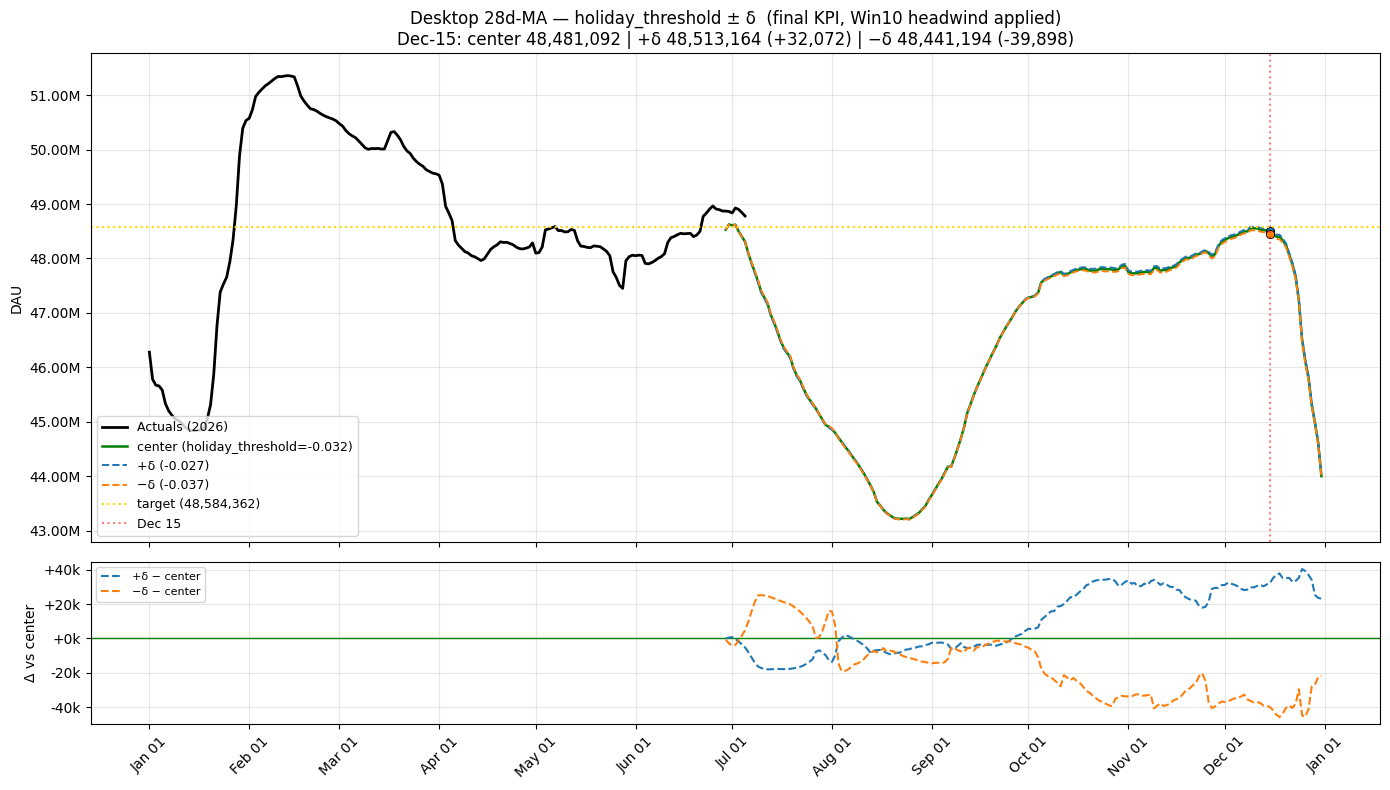

saved research/param-scans/plots/desktop_gradient_round1/thresh.png


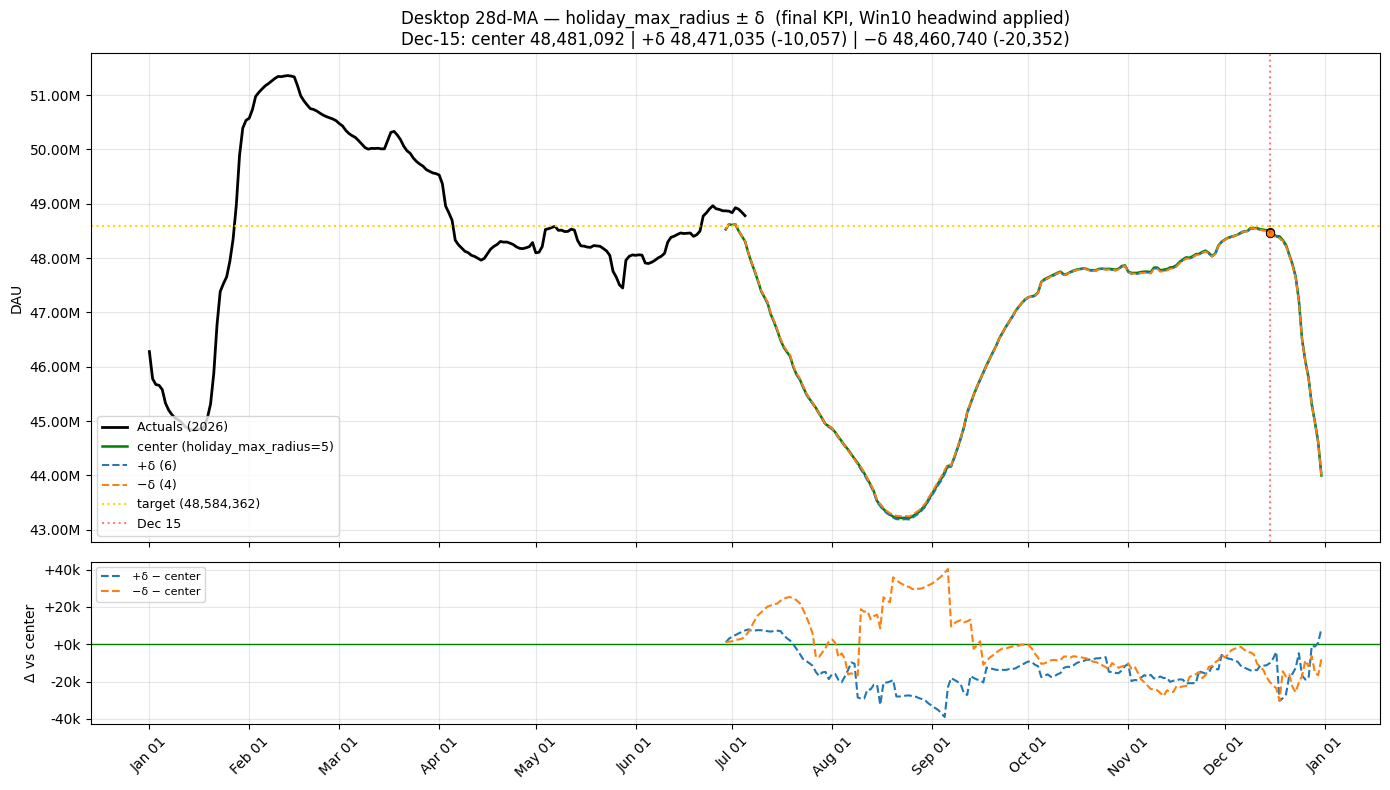

saved research/param-scans/plots/desktop_gradient_round1/hmaxr.png


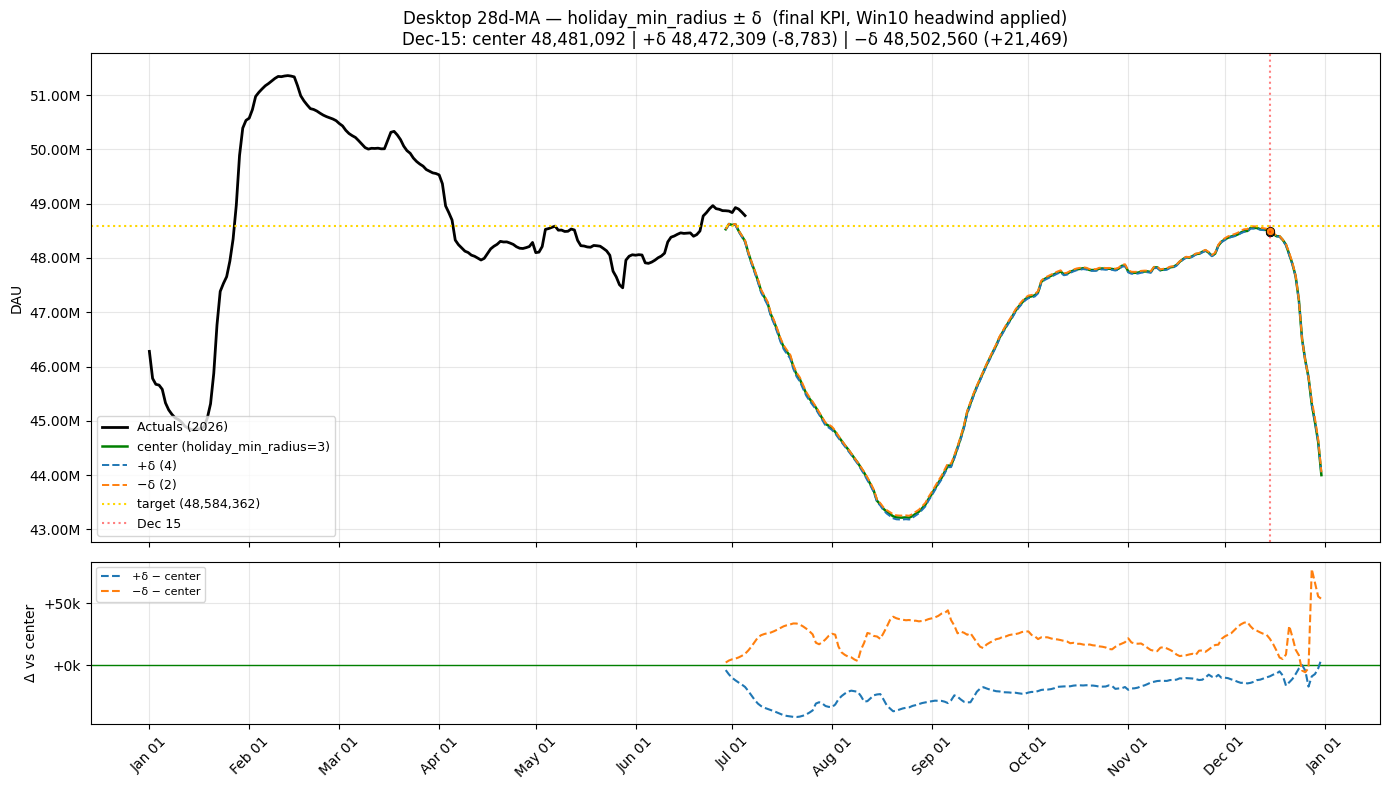

saved research/param-scans/plots/desktop_gradient_round1/hminr.png


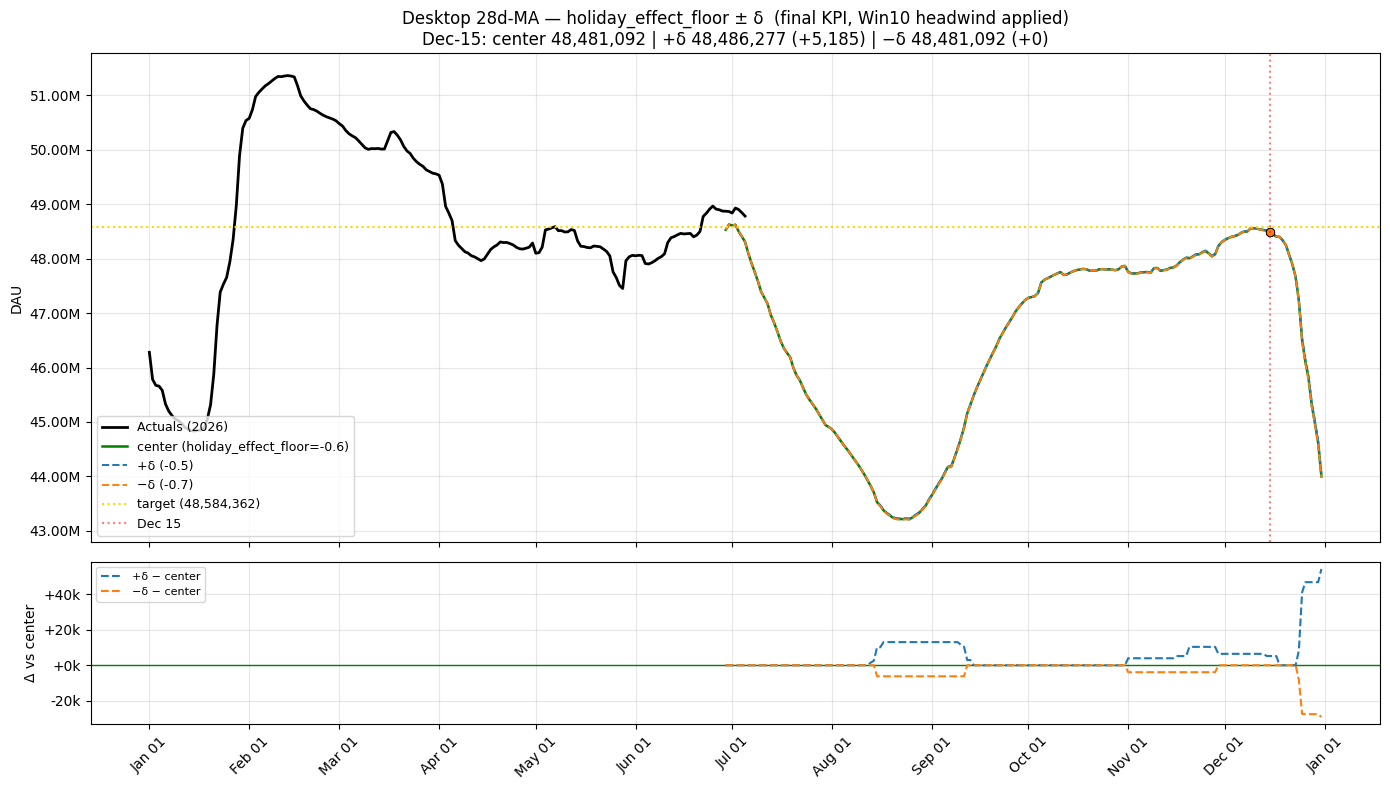

saved research/param-scans/plots/desktop_gradient_round1/clip.png


In [6]:
# [per-parameter-plots]
# One canonical-format figure per parameter: actuals (Jan 1 →) + center/+δ/−δ forecast curves in
# final KPI space (headwind applied), plus a divergence subplot so small effects stay visible.
def millions_formatter(x, pos):
    return f"{x / 1e6:.2f}M"


def clip_display(s):
    return s[(s.index >= DISPLAY_START) & (s.index <= DISPLAY_END)].dropna()


def clip_forecast_only(s):
    return s[(s.index >= FORECAST_START) & (s.index <= DISPLAY_END)].dropna()


center_ma = forecast_ma_final(find_probe_parquet("center"))

for field, short, ctr, minus, plus in PARAMS:
    ma_p = forecast_ma_final(find_probe_parquet(f"{short}__plus"))
    ma_m = forecast_ma_final(find_probe_parquet(f"{short}__minus"))
    cf = center_ma.loc[MEASUREMENT_DATE]
    pf = ma_p.loc[MEASUREMENT_DATE]
    mf = ma_m.loc[MEASUREMENT_DATE]

    fig, (ax, ax2) = plt.subplots(
        2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

    # Top: canonical forecast format.
    ax.plot(clip_display(desktop_actual_ma), color="black", lw=2, label="Actuals (2026)")
    ax.plot(clip_forecast_only(center_ma), color="green", lw=1.8,
            label=f"center ({LABELS[short]}={ctr})")
    ax.plot(clip_forecast_only(ma_p), color="#1f77b4", lw=1.4, ls="--", label=f"+δ ({plus})")
    ax.plot(clip_forecast_only(ma_m), color="#ff7f0e", lw=1.4, ls="--", label=f"−δ ({minus})")
    for ma, col in [(center_ma, "green"), (ma_p, "#1f77b4"), (ma_m, "#ff7f0e")]:
        ax.plot(MEASUREMENT_DATE, ma.loc[MEASUREMENT_DATE], marker="o", color=col,
                ms=6, mec="black", mew=0.6)
    ax.axhline(TARGET_FINAL, color="gold", ls=":", lw=1.5, label=f"target ({TARGET_FINAL:,})")
    ax.axvline(MEASUREMENT_DATE, color="red", ls=":", alpha=0.5, label="Dec 15")
    ax.set_title(
        f"Desktop 28d-MA — {LABELS[short]} ± δ  (final KPI, Win10 headwind applied)\n"
        f"Dec-15: center {cf:,.0f} | +δ {pf:,.0f} ({pf - cf:+,.0f}) | "
        f"−δ {mf:,.0f} ({mf - cf:+,.0f})", fontsize=12)
    ax.set_ylabel("DAU")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
    ax.legend(loc="lower left", fontsize=9)
    ax.grid(True, alpha=0.3)

    # Bottom: divergence from center (thousands) — makes tiny effects legible.
    ax2.axhline(0, color="green", lw=1)
    ax2.plot(clip_forecast_only(ma_p - center_ma).index,
             clip_forecast_only(ma_p - center_ma).values, color="#1f77b4", ls="--", label="+δ − center")
    ax2.plot(clip_forecast_only(ma_m - center_ma).index,
             clip_forecast_only(ma_m - center_ma).values, color="#ff7f0e", ls="--", label="−δ − center")
    ax2.set_ylabel("Δ vs center")
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:+.0f}k"))
    ax2.legend(loc="upper left", fontsize=8)
    ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax2.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

    plt.tight_layout()
    out = f"{PLOTS_DIR}/{short}.png"
    plt.savefig(out, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"saved {out}")
